In [7]:
import re
import sys
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
import seaborn as sns

# Ensure project root is in path
PROJECT_ROOT = Path(__file__).resolve().parent.parent if "__file__" in globals() else Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.graph_analysis import (
    calculate_moments_error,
    calculate_annd_error,
    calculate_eccentricity_error,
)

In [8]:
# Exactly ONE of the three variables should be None at a time; the other two
# must be set to a single valid string from the canonical orders below.
FIXED_METHODS:  str | None = None            # set to None to vary methods (methods vary)
FIXED_SAMPLERS: str | None = "nosampler"     # chosen and fixed
FIXED_FEATURES: str | None = "log_bin_deg"   # chosen and fixed

SYNTHETIC_DATA_DIR = PROJECT_ROOT / "synthetic_data"
DATASET_NAMES = ["BZR", "DHFR", "Mutagenicity", "MUTAG"]

# Cache original dataset statistics for target secondary metrics
original_stats_cache = {}
for dname in DATASET_NAMES:
    orig_path = PROJECT_ROOT / "data" / dname / f"{dname}_original.pt"
    if orig_path.exists():
        try:
            payload = torch.load(orig_path, map_location="cpu", weights_only=False)
            original_stats_cache[dname] = payload.get("metadata", {}).get("per_graph_statistics", [])
        except Exception as e:
            print(f"Warning: Failed to load original dataset statistics for {dname}: {e}")

# Methods
METHOD_ORDER = ["dummyNodes", "dummyEdges", "padma", "anndg", "anndgD", "anndgE", "anndgED"]
METHOD_PALETTE = {
    "original":   "#5B9BD5",
    "dummyNodes": "#DA7CF7",
    "dummyEdges": "#98C379",
    "padma":      "#F5C431",
    "anndg":      "#E06C75",
    "anndgD":     "#5CE9FF",
    "anndgE":     "#C47900",
    "anndgED":    "#5242D1",
}

def _canonical_order(values, order):
    """Return values sorted by canonical order, with unknown values appended."""
    present = set(values)
    return [v for v in order if v in present] + sorted(v for v in present if v not in order)

def safe_array(val, expected_length=4):
    """Safely convert any value to a float 1D numpy array of expected length."""
    if val is None:
        return np.zeros(expected_length)
    if isinstance(val, (list, np.ndarray)):
        arr = np.array(val, dtype=float)
        if len(arr) == expected_length:
            return arr
    arr = np.atleast_1d(val).astype(float)
    if len(arr) < expected_length:
        pad = np.zeros(expected_length - len(arr))
        arr = np.concatenate([arr, pad])
    return arr[:expected_length]

def load_fidelity_data() -> pd.DataFrame:
    """Loads and aggregates target fidelity statistics from synthetic dataset metadata."""
    sampler_alts = "|".join(re.escape(s) for s in ["nosampler", "moments", "percentile", "percentile_corr", "gmcm"])
    filename_pattern = re.compile(
        r"(?P<dataset>[A-Za-z][A-Za-z0-9\-]*)_"          # dataset name
        r"(?P<method>[A-Za-z][A-Za-z0-9]*)_"             # method name
        r"(?P<sampler>" + sampler_alts + r")_"           # sampler (exact match)
        r"(?P<feature>[a-zA-Z0-9_]+)_"                   # feature strategy
        r"v(?P<variant>\d+)\.pt$"                        # variant index
    )

    rows = []
    pt_paths = list(SYNTHETIC_DATA_DIR.glob("*.pt"))
    if not pt_paths:
        raise FileNotFoundError(f"No synthetic .pt files found in {SYNTHETIC_DATA_DIR}.")

    print(f"Scanning {len(pt_paths)} files in {SYNTHETIC_DATA_DIR}...")
    
    for pt_path in pt_paths:
        match = filename_pattern.match(pt_path.name)
        if match is None:
            continue
            
        dataset = match.group("dataset")
        method = match.group("method")
        sampler = match.group("sampler")
        feature = match.group("feature")
        variant = int(match.group("variant"))

        if dataset not in DATASET_NAMES:
            continue
        if FIXED_SAMPLERS is not None and sampler != FIXED_SAMPLERS:
            continue
        if FIXED_FEATURES is not None and feature != FIXED_FEATURES:
            continue
        if FIXED_METHODS is not None and method != FIXED_METHODS:
            continue

        try:
            payload = torch.load(pt_path, map_location="cpu", weights_only=False)
            metadata = payload.get("metadata", {})
        except Exception as e:
            print(f"Warning: Failed to load {pt_path.name}: {e}")
            continue

        target_stats = metadata.get("per_graph_target_statistics", [])
        actual_stats = metadata.get("per_graph_statistics", [])

        if not target_stats or not actual_stats:
            continue

        n_graphs = min(len(target_stats), len(actual_stats))
        for i in range(n_graphs):
            t_stat = target_stats[i]
            a_stat = actual_stats[i]

            if t_stat is None or a_stat is None:
                continue

            # Core topological features
            t_n_nodes = t_stat.get("n_nodes")
            a_n_nodes = a_stat.get("n_nodes")
            t_n_edges = t_stat.get("n_edges")
            a_n_edges = a_stat.get("n_edges")

            # Degree moments (length 4)
            t_moments = safe_array(t_stat.get("degree_moments"))
            a_moments = safe_array(a_stat.get("degree_moments"))

            # ANND (length 4)
            t_annd = safe_array(t_stat.get("annd"))
            a_annd = safe_array(a_stat.get("annd"))

            # Eccentricity (length 4)
            t_ecc = safe_array(t_stat.get("eccentricity"))
            a_ecc = safe_array(a_stat.get("eccentricity"))

            # Retrieve target secondary metrics from caching of original datasets
            orig_stat = {}
            if dataset in original_stats_cache and i < len(original_stats_cache[dataset]):
                orig_stat = original_stats_cache[dataset][i]

            t_clustering = orig_stat.get("clustering")
            t_assortativity = orig_stat.get("assortativity")
            t_modularity = orig_stat.get("modularity")
            t_efficiency = orig_stat.get("efficiency")

            row = {
                "dataset": dataset,
                "method": method,
                "sampler": sampler,
                "feature": feature,
                "variant": variant,
                "graph_idx": i,
                
                # Topological counts & structures (Target vs Actual)
                "target_n_nodes": t_n_nodes,
                "actual_n_nodes": a_n_nodes,
                "target_n_edges": t_n_edges,
                "actual_n_edges": a_n_edges,
                
                # Degree Moments Detail
                "target_deg_mean": t_moments[0],
                "target_deg_var": t_moments[1],
                "target_deg_skew": t_moments[2],
                "target_deg_kurt": t_moments[3],
                "actual_deg_mean": a_moments[0],
                "actual_deg_var": a_moments[1],
                "actual_deg_skew": a_moments[2],
                "actual_deg_kurt": a_moments[3],
                
                # Secondary metrics (Target vs Actual)
                "target_clustering": t_clustering,
                "actual_clustering": a_stat.get("clustering"),
                "target_assortativity": t_assortativity,
                "actual_assortativity": a_stat.get("assortativity"),
                "target_modularity": t_modularity,
                "actual_modularity": a_stat.get("modularity"),
                "target_efficiency": t_efficiency,
                "actual_efficiency": a_stat.get("efficiency"),
                "target_diameter": t_stat.get("diameter"),
                "actual_diameter": a_stat.get("diameter"),
            }

            # Detail bins for ANND and Eccentricity
            for idx in range(4):
                row[f"target_annd_{idx}"] = t_annd[idx]
                row[f"actual_annd_{idx}"] = a_annd[idx]
                row[f"target_eccentricity_{idx}"] = t_ecc[idx]
                row[f"actual_eccentricity_{idx}"] = a_ecc[idx]

            rows.append(row)

    if not rows:
        raise ValueError(f"No matching data loaded. Check settings: FIXED_SAMPLERS={FIXED_SAMPLERS}, FIXED_FEATURES={FIXED_FEATURES}")

    df_fidelity = pd.DataFrame(rows)
    
    # Set categorical orders for consistency in plotting
    all_methods = set(df_fidelity["method"].dropna())
    ordered_m = _canonical_order(all_methods, METHOD_ORDER)
    df_fidelity["method"] = pd.Categorical(df_fidelity["method"], categories=ordered_m, ordered=True)
    
    print(f"Successfully loaded {len(df_fidelity)} records representing raw fidelity statistics for {len(all_methods)} methods.")
    return df_fidelity

def compute_fidelity_errors(df: pd.DataFrame) -> pd.DataFrame:
    """Computes structural error metrics from target vs actual graph statistics."""
    error_rows = []
    
    print(f"Computing structural errors for {len(df)} records...")
    
    for idx, row in df.iterrows():
        err_row = {
            "dataset": row["dataset"],
            "method": row["method"],
            "sampler": row["sampler"],
            "feature": row["feature"],
            "variant": row["variant"],
            "graph_idx": row["graph_idx"],
        }
        
        # Absolute Errors for scalar counts
        err_row["nodes_error"] = abs(row["actual_n_nodes"] - row["target_n_nodes"])
        err_row["edges_error"] = abs(row["actual_n_edges"] - row["target_n_edges"])
        
        # Absolute Errors for secondary metrics
        for metric in ["clustering", "assortativity", "modularity", "efficiency", "diameter"]:
            t_val = row[f"target_{metric}"]
            a_val = row[f"actual_{metric}"]
            if t_val is not None and a_val is not None and not pd.isna(t_val) and not pd.isna(a_val):
                err_row[f"{metric}_error"] = abs(a_val - t_val)
            else:
                err_row[f"{metric}_error"] = np.nan
        
        # Specialized Errors for degree moments
        t_moments = np.array([
            row["target_deg_mean"],
            row["target_deg_var"],
            row["target_deg_skew"],
            row["target_deg_kurt"]
        ])
        a_moments = np.array([
            row["actual_deg_mean"],
            row["actual_deg_var"],
            row["actual_deg_skew"],
            row["actual_deg_kurt"]
        ])
        err_row["moments_error"] = calculate_moments_error(a_moments, t_moments)
        
        # Specialized Errors for ANND
        t_annd = np.array([row[f"target_annd_{i}"] for i in range(4)])
        a_annd = np.array([row[f"actual_annd_{i}"] for i in range(4)])
        err_row["annd_error"] = calculate_annd_error(a_annd, t_annd)
        
        # Specialized Errors for Eccentricity
        t_ecc = np.array([row[f"target_eccentricity_{i}"] for i in range(4)])
        a_ecc = np.array([row[f"actual_eccentricity_{i}"] for i in range(4)])
        err_row["eccentricity_error"] = calculate_eccentricity_error(a_ecc, t_ecc)
        
        error_rows.append(err_row)
        
    df_errors = pd.DataFrame(error_rows)
    
    # Ensure canonical ordering on methods
    if "method" in df_errors.columns:
        df_errors["method"] = pd.Categorical(df_errors["method"], categories=df["method"].cat.categories, ordered=True)
        
    print(f"Successfully computed errors. Created error DataFrame with shape {df_errors.shape}.")
    return df_errors

df_fidelity = load_fidelity_data()
df_errors = compute_fidelity_errors(df_fidelity)

# Derived globals (similar to gnn_result_analysis.py)
METHODS = sorted(df_fidelity["method"].dropna().unique().tolist())
DATASETS = sorted(df_fidelity["dataset"].dropna().unique().tolist())

display(df_fidelity.head(10))
display(df_errors.head(10))

Scanning 480 files in /home/amarigo/syn_bench_gnn2/syn_bench_gnn/synthetic_data...
Successfully loaded 191160 records representing raw fidelity statistics for 6 methods.
Computing structural errors for 191160 records...
Successfully computed errors. Created error DataFrame with shape (191160, 16).


,dataset,method,sampler,feature,variant,graph_idx,target_n_nodes,actual_n_nodes,target_n_edges,actual_n_edges,...,target_eccentricity_1,actual_eccentricity_1,target_annd_2,actual_annd_2,target_eccentricity_2,actual_eccentricity_2,target_annd_3,actual_annd_3,target_eccentricity_3,actual_eccentricity_3
0,Mutagenicity,dummyNodes,nosampler,log_bin_deg,8,0,16,16,16,17,...,0.400000,0.283333,0.155556,0.194444,0.266667,0.250000,0.155556,0.185185,0.366667,0.244444
1,Mutagenicity,dummyNodes,nosampler,log_bin_deg,8,1,11,11,11,7,...,0.466667,0.233333,0.211111,0.150000,0.400000,0.150000,0.233333,0.116667,0.350000,0.150000
2,Mutagenicity,dummyNodes,nosampler,log_bin_deg,8,2,17,17,17,20,...,0.328125,0.343750,0.184896,0.174479,0.281250,0.312500,0.136719,0.200521,0.265625,0.265625
3,Mutagenicity,dummyNodes,nosampler,log_bin_deg,8,3,13,13,12,8,...,0.333333,0.375000,0.250000,0.187500,0.305556,0.375000,0.180556,0.118056,0.222222,0.500000
4,Mutagenicity,dummyNodes,nosampler,log_bin_deg,8,4,38,38,39,6,...,0.345946,0.045045,0.069069,0.027027,0.282282,0.027027,0.057307,0.040541,0.324324,0.054054
5,Mutagenicity,dummyNodes,nosampler,log_bin_deg,8,5,20,20,21,14,...,0.347368,0.105263,0.140351,0.118421,0.252632,0.171053,0.114035,0.106360,0.294737,0.131579
6,Mutagenicity,dummyNodes,nosampler,log_bin_deg,8,6,31,31,33,58,...,0.245833,0.154167,0.086111,0.149375,0.212500,0.137500,0.080159,0.139796,0.195238,0.138095
7,Mutagenicity,dummyNodes,nosampler,log_bin_deg,8,7,16,16,16,19,...,0.366667,0.250000,0.133333,0.208333,0.316667,0.266667,0.177778,0.216667,0.283333,0.200000
8,Mutagenicity,dummyNodes,nosampler,log_bin_deg,8,8,13,13,12,18,...,0.500000,0.277778,0.226852,0.296296,0.361111,0.250000,0.136574,0.245833,0.361111,0.250000
9,Mutagenicity,dummyNodes,nosampler,log_bin_deg,8,9,106,106,106,0,...,0.280381,0.000000,0.024063,0.000000,0.275429,0.000000,0.023512,0.000000,0.246825,0.000000


,dataset,method,sampler,feature,variant,graph_idx,nodes_error,edges_error,clustering_error,assortativity_error,modularity_error,efficiency_error,diameter_error,moments_error,annd_error,eccentricity_error
0,Mutagenicity,dummyNodes,nosampler,log_bin_deg,8,0,0,1,NaN,NaN,NaN,NaN,2.0,0.254652,0.248373,0.888398
1,Mutagenicity,dummyNodes,nosampler,log_bin_deg,8,1,0,4,NaN,NaN,NaN,NaN,2.0,1.265264,0.691815,1.681379
2,Mutagenicity,dummyNodes,nosampler,log_bin_deg,8,2,0,3,NaN,NaN,NaN,NaN,1.0,0.546000,0.359019,0.082316
3,Mutagenicity,dummyNodes,nosampler,log_bin_deg,8,3,0,4,NaN,NaN,NaN,NaN,3.0,0.485541,0.750423,1.165007
4,Mutagenicity,dummyNodes,nosampler,log_bin_deg,8,4,0,33,NaN,NaN,NaN,NaN,12.0,1.042646,0.297467,1.938281
5,Mutagenicity,dummyNodes,nosampler,log_bin_deg,8,5,0,7,NaN,NaN,NaN,NaN,3.0,0.520898,0.185469,1.248059
6,Mutagenicity,dummyNodes,nosampler,log_bin_deg,8,6,0,25,NaN,NaN,NaN,NaN,3.0,0.286780,0.340775,0.649980
7,Mutagenicity,dummyNodes,nosampler,log_bin_deg,8,7,0,3,NaN,NaN,NaN,NaN,1.0,0.559441,0.497705,0.879530
8,Mutagenicity,dummyNodes,nosampler,log_bin_deg,8,8,0,6,NaN,NaN,NaN,NaN,2.0,0.787555,0.686041,1.171231
9,Mutagenicity,dummyNodes,nosampler,log_bin_deg,8,9,0,106,NaN,NaN,NaN,NaN,37.0,0.238835,0.151319,1.870501


/tmp/ipykernel_909236/4223580250.py:273: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_df = sub_df.groupby("method")[error_metrics].mean().T
/tmp/ipykernel_909236/4223580250.py:302: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_labels = summary_df.applymap(format_annotation)


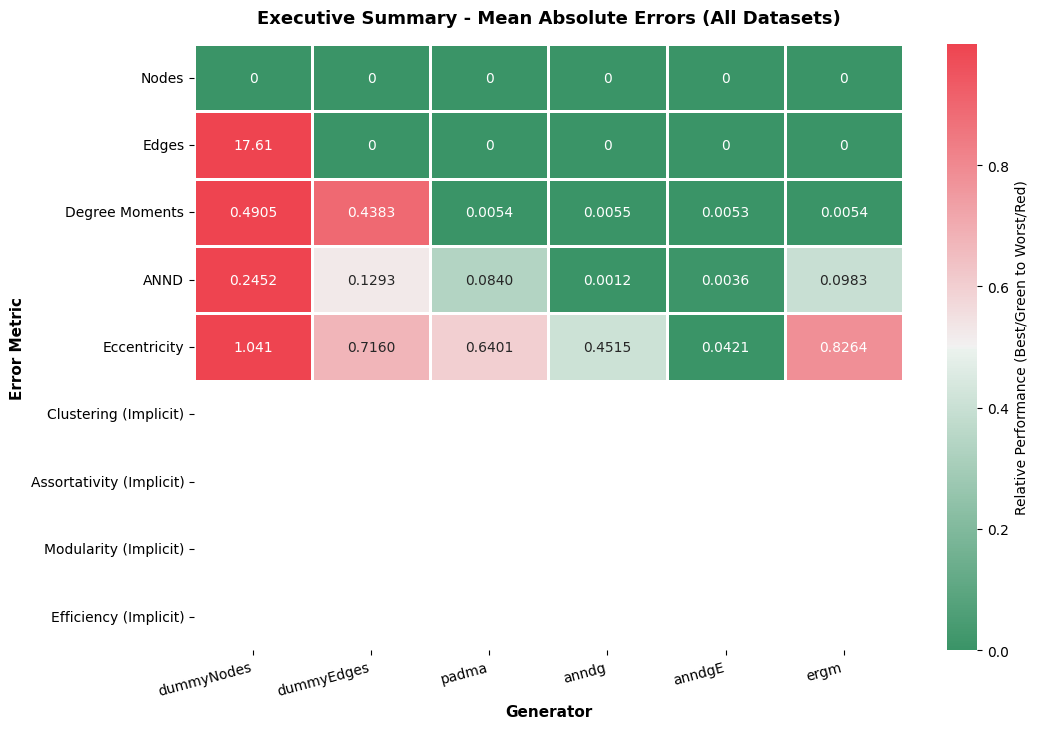

In [9]:
import matplotlib.ticker as mticker

def plot_target_vs_actual(df: pd.DataFrame, metric: str, dataset_name: str | None = None, ax: plt.Axes | None = None):
    """1. Scatter Plot "Target vs Generato" with y = x diagonal.
    
    Shows fine-grained target replication fidelity on a graph-by-graph level.
    Perfect replication lies exactly on the dashed diagonal y = x.
    """
    if dataset_name is not None:
        sub_df = df[df["dataset"] == dataset_name]
        title = f"{metric} - Target vs Generated ({dataset_name})"
    else:
        sub_df = df
        title = f"{metric} - Target vs Generated (All Datasets)"
        
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))
        
    t_col = f"target_{metric}"
    a_col = f"actual_{metric}"
    
    # Scatter plot for each method
    sns.scatterplot(
        data=sub_df,
        x=t_col,
        y=a_col,
        hue="method",
        palette=METHOD_PALETTE,
        alpha=0.6,
        edgecolor="none",
        s=25,
        ax=ax
    )
    
    # Calculate limits for diagonal line
    min_val = min(sub_df[t_col].min(), sub_df[a_col].min())
    max_val = max(sub_df[t_col].max(), sub_df[a_col].max())
    
    # Perfect diagonal
    ax.plot([min_val, max_val], [min_val, max_val], color="#2C3E50", linestyle="--", linewidth=1.5, label="Perfect Replica (y=x)")
    
    ax.set_xlabel(f"Target {metric}", fontsize=11, fontweight="bold")
    ax.set_ylabel(f"Generated {metric}", fontsize=11, fontweight="bold")
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.legend(frameon=True, facecolor="white", edgecolor="none")
    ax.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    return

def plot_error_distributions(df_errors: pd.DataFrame, metrics: list[str], dataset_name: str | None = None, use_violin: bool = False):
    """2. Boxplot or Violin Plot of Absolute Errors side-by-side.
    
    Compares the full distribution of errors across different methods.
    The y-axis represents the error magnitude. Closer to 0 is better.
    We split the metrics into "Targeted (Active)" and "Emergent (Implicit)" groups.
    """
    if dataset_name is not None:
        sub_df = df_errors[df_errors["dataset"] == dataset_name]
        title = f"Absolute Error Distributions ({dataset_name})"
    else:
        sub_df = df_errors
        title = "Absolute Error Distributions (All Datasets)"
        
    # Melt the dataframe
    df_melted = sub_df.melt(
        id_vars=["dataset", "method", "sampler", "feature", "variant", "graph_idx"],
        value_vars=metrics,
        var_name="Error Type",
        value_name="Error Value"
    )
    
    # Map raw names to user-friendly titles
    friendly_names = {
        "nodes_error": "Nodes",
        "edges_error": "Edges",
        "moments_error": "Degree Moments",
        "annd_error": "ANND",
        "eccentricity_error": "Eccentricity",
        "clustering_error": "Clustering (Implicit)",
        "assortativity_error": "Assortativity (Implicit)",
        "modularity_error": "Modularity (Implicit)",
        "efficiency_error": "Efficiency (Implicit)",
        "diameter_error": "Diameter (Implicit)"
    }
    df_melted["Error Type"] = df_melted["Error Type"].map(friendly_names)
    
    # Subplots to handle different y-scales perfectly!
    n_metrics = len(metrics)
    fig, axes = plt.subplots(1, n_metrics, figsize=(3.8 * n_metrics, 5.5), sharey=False)
    if n_metrics == 1:
        axes = [axes]
        
    unique_types = [friendly_names[m] for m in metrics]
    
    for i, err_type in enumerate(unique_types):
        ax = axes[i]
        subset = df_melted[df_melted["Error Type"] == err_type]
        
        # Color background based on Active vs Implicit
        is_implicit = "(Implicit)" in err_type
        bg_color = "#FDF2E9" if is_implicit else "#EBF5FB"
        ax.set_facecolor(bg_color)
        
        if use_violin:
            sns.violinplot(
                data=subset,
                x="Error Type",
                y="Error Value",
                hue="method",
                palette=METHOD_PALETTE,
                inner="quartile",
                split=False,
                ax=ax
            )
        else:
            sns.boxplot(
                data=subset,
                x="Error Type",
                y="Error Value",
                hue="method",
                palette=METHOD_PALETTE,
                showfliers=False,
                width=0.6,
                ax=ax
            )
            
        ax.set_xlabel("")
        ax.set_ylabel("Absolute Error", fontsize=10, fontweight="bold")
        ax.set_title(err_type, fontsize=11, fontweight="bold", pad=8)
        ax.grid(True, linestyle=":", alpha=0.5)
        
        # Remove individual legends except the last one
        if i < n_metrics - 1:
            if ax.get_legend() is not None:
                ax.get_legend().remove()
        else:
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Generator")
            
    fig.suptitle(title, fontsize=14, fontweight="bold", y=0.98)
    plt.tight_layout()
    return

def plot_implicit_density_grid(df: pd.DataFrame, metrics: list[str], dataset_name: str | None = None):
    """3. Facet Grid of Density Curves (KDE) comparing Target vs. Generators.
    
    Ideal for emergent (implicit) properties. Demonstrates whether the overall
    distribution shape was correctly captured, even if exact pairing is noisy.
    """
    if dataset_name is not None:
        sub_df = df[df["dataset"] == dataset_name]
        title = f"Emergent Distribution Fidelity (KDE) - {dataset_name}"
    else:
        sub_df = df
        title = "Emergent Distribution Fidelity (KDE) - All Datasets"
        
    n_metrics = len(metrics)
    cols = min(2, n_metrics)
    rows = (n_metrics + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(5.5 * cols, 4.5 * rows))
    axes = np.atleast_1d(axes).flatten()
    
    methods = sub_df["method"].cat.categories
    
    friendly_names = {
        "clustering": "Clustering Coefficient",
        "assortativity": "Assortativity",
        "modularity": "Modularity",
        "efficiency": "Global Efficiency",
        "diameter": "Diameter"
    }
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        
        # Plot Target KDE
        sns.kdeplot(
            data=sub_df,
            x=f"target_{metric}",
            label="Target (Original)",
            color="#5C6BC0",
            linestyle="--",
            linewidth=2.5,
            fill=True,
            alpha=0.1,
            ax=ax
        )
        
        # Plot Generator KDEs
        for method in methods:
            m_subset = sub_df[sub_df["method"] == method]
            if not m_subset.empty:
                sns.kdeplot(
                    data=m_subset,
                    x=f"actual_{metric}",
                    label=f"Generated ({method})",
                    color=METHOD_PALETTE[method],
                    linewidth=1.8,
                    ax=ax
                )
                
        ax.set_title(friendly_names.get(metric, metric), fontsize=12, fontweight="bold")
        ax.set_xlabel("Metric Value", fontsize=10)
        ax.set_ylabel("Density", fontsize=10)
        ax.grid(True, linestyle=":", alpha=0.6)
        
        if i == 0:
            ax.legend(frameon=True, facecolor="white", edgecolor="none")
        else:
            if ax.get_legend() is not None:
                ax.get_legend().remove()
                
    # Hide empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    fig.suptitle(title, fontsize=14, fontweight="bold", y=0.98)
    plt.tight_layout()
    return

def plot_error_cdf(df_errors: pd.DataFrame, error_metric: str, dataset_name: str | None = None):
    """4. Cumulative Distribution Function (CDF) of Errors.
    
    Scientifically proves stochastic dominance. A curve that rises faster
    towards 1.0 (moving up and to the left) represents a superior generator.
    """
    if dataset_name is not None:
        sub_df = df_errors[df_errors["dataset"] == dataset_name]
        title = f"CDF of {error_metric.replace('_', ' ').title()} ({dataset_name})"
    else:
        sub_df = df_errors[(df_errors["method"] == "padma") | (df_errors["method"] == "anndg") | (df_errors["method"] == "anndgE") | (df_errors["method"] == "anndgD")]
        title = f"CDF of {error_metric.replace('_', ' ').title()} (All Datasets)"
        
    fig, ax = plt.subplots(figsize=(7, 5))
    
    sns.ecdfplot(
        data=sub_df,
        x=error_metric,
        hue="method",
        palette=METHOD_PALETTE,
        linewidth=2.5,
        ax=ax
    )
    ax.set_xlim(0, 0.3)
    ax.set_xlabel("Absolute Error", fontsize=11, fontweight="bold")
    ax.set_ylabel("Cumulative Probability (Fraction of Graphs)", fontsize=11, fontweight="bold")
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.grid(True, linestyle=":", alpha=0.6)
    
    # Style legend
    if ax.get_legend() is not None:
        ax.get_legend().set_title("Generator")
        
    plt.tight_layout()
    return

def plot_executive_error_heatmap(df_errors: pd.DataFrame, error_metrics: list[str], dataset_name: str | None = None):
    """5. Executive Summary Heatmap showing mean structural error.
    
    Rows are structural statistics, columns are generators.
    Cells show the raw Mean Absolute Error (MAE), color-coded by relative performance
    using a green (low error/best) -> yellow (medium) -> red (high error/worst) gradient.
    Very small errors are formatted in scientific notation for high precision.
    """
    if dataset_name is not None:
        sub_df = df_errors[df_errors["dataset"] == dataset_name]
        title = f"Executive Summary - Mean Absolute Errors ({dataset_name})"
    else:
        sub_df = df_errors
        title = "Executive Summary - Mean Absolute Errors (All Datasets)"
        
    # Compute Mean Absolute Error for each method
    summary_df = sub_df.groupby("method")[error_metrics].mean().T
    
    friendly_names = {
        "nodes_error": "Nodes",
        "edges_error": "Edges",
        "moments_error": "Degree Moments",
        "annd_error": "ANND",
        "eccentricity_error": "Eccentricity",
        "clustering_error": "Clustering (Implicit)",
        "assortativity_error": "Assortativity (Implicit)",
        "modularity_error": "Modularity (Implicit)",
        "efficiency_error": "Efficiency (Implicit)",
        "diameter_error": "Diameter (Implicit)"
    }
    
    summary_df.index = summary_df.index.map(friendly_names)
    
    # Custom cell formatting: scientific notation for small positive values (< 0.01)
    def format_annotation(val):
        if pd.isna(val):
            return ""
        if abs(val) < 1e-12:
            return "0"
        if abs(val) < 1:
            return f"{val:.4f}"
        if abs(val) < 10:
            return f"{val:.3f}"
        return f"{val:.2f}"
        
    annot_labels = summary_df.applymap(format_annotation)
    
    # Colormap Data
    row_min = summary_df.min(axis=1).values[:, np.newaxis]
    row_max = summary_df.max(axis=1).values[:, np.newaxis]
    color_data = (summary_df.values - row_min) / (row_max - row_min + 1e-8)
    color_df = pd.DataFrame(color_data, index=summary_df.index, columns=summary_df.columns)
        
    fig, ax = plt.subplots(figsize=(8 + 0.5 * len(summary_df.columns), 0.6 * len(error_metrics) + 2))
    
    # We use a color map where green is low error and red is high error
    cmap = sns.diverging_palette(145, 10, s=80, l=55, as_cmap=True)
    
    # Draw heatmap
    sns.heatmap(
        color_df,
        annot=annot_labels,
        fmt="",  # Must be empty as annot_labels already contains pre-formatted strings
        cmap=cmap,
        linewidths=0.8,
        cbar_kws={"label": "Relative Performance (Best/Green to Worst/Red)"},
        ax=ax
    )
    
    ax.set_title(title, fontsize=13, fontweight="bold", pad=15)
    ax.set_ylabel("Error Metric", fontsize=11, fontweight="bold")
    ax.set_xlabel("Generator", fontsize=11, fontweight="bold")
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    return

# plot_target_vs_actual(df_fidelity, metric="assortativity")
# plot_error_distributions(df_errors, metrics=["nodes_error", "clustering_error"])
# plot_implicit_density_grid(df_fidelity, metrics=["clustering", "assortativity"])
# plot_error_cdf(df_errors, error_metric="moments_error")
plot_executive_error_heatmap(df_errors, error_metrics=["nodes_error", "edges_error", "moments_error", "annd_error", "eccentricity_error", "clustering_error", "assortativity_error", "modularity_error", "efficiency_error"])